In [2]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm
from scipy.interpolate import griddata

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.stats import gaussian_kde
from scipy.ndimage.filters import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_91992/4184058898.py:31: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [3]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
file_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [4]:
with open(file_dir+'galaxies_tng300_072_hmc_lensing_prof_types.txt','rb') as f:
    lensing_cat=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)
mask=(tab['proj']=='xy')
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [5]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [6]:
def random_noise_on_richness(data,error=2,times=30):
    n=len(data)
    data0=np.asarray([[data]])
    for i in range(times):
        data0=np.append(data0,[[data+np.random.normal(loc=0,scale=error,size=n)]],axis=1)
    data1=data0[0].T
    data_mean=np.sum(data1,axis=1)/times
    return data_mean

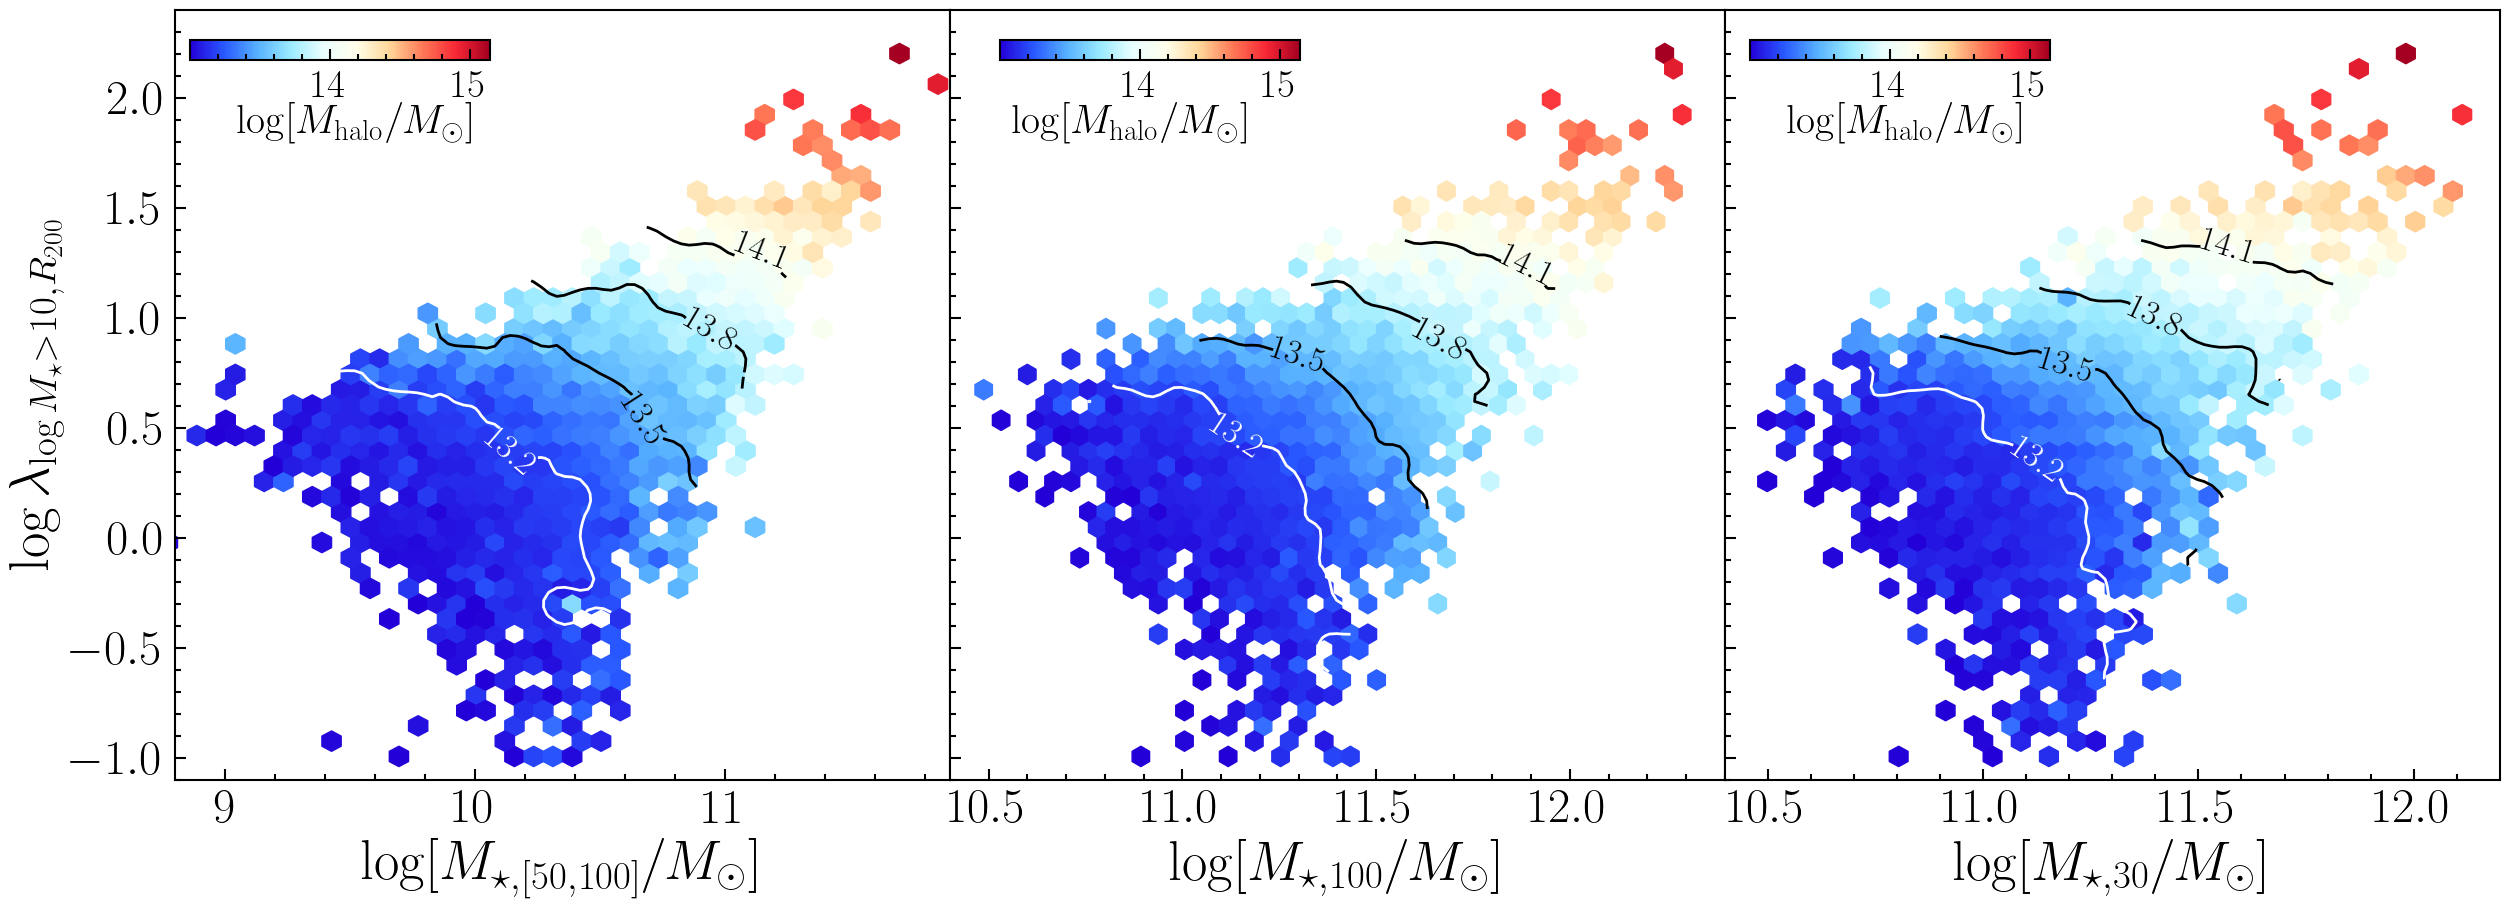

In [16]:
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
axlist=gs.subplots(sharey='row')
top_numb=600
sigma0=1.5

ax3=axlist[0]

name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(10,0.2),(10.6,0.5),(11,1),(11.2,1.4)],fontsize=25)

ax3.set_ylabel(label,fontsize=40)
ax3.set_xlabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(8.8,11.9)
ax3=axlist[1]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.4, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11.0,0),(11.3,0.8),(11.7,1),(11.9,1.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,100}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(10.4,12.4)
ax3=axlist[2]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_30_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11.0,0),(11.2,0.8),(11.4,1),(11.6,1.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(10.4,12.2)

plt.savefig(fig_dir+'Fig11.pdf',bbox_inches='tight',dpi=100)

(10.4, 12.2)

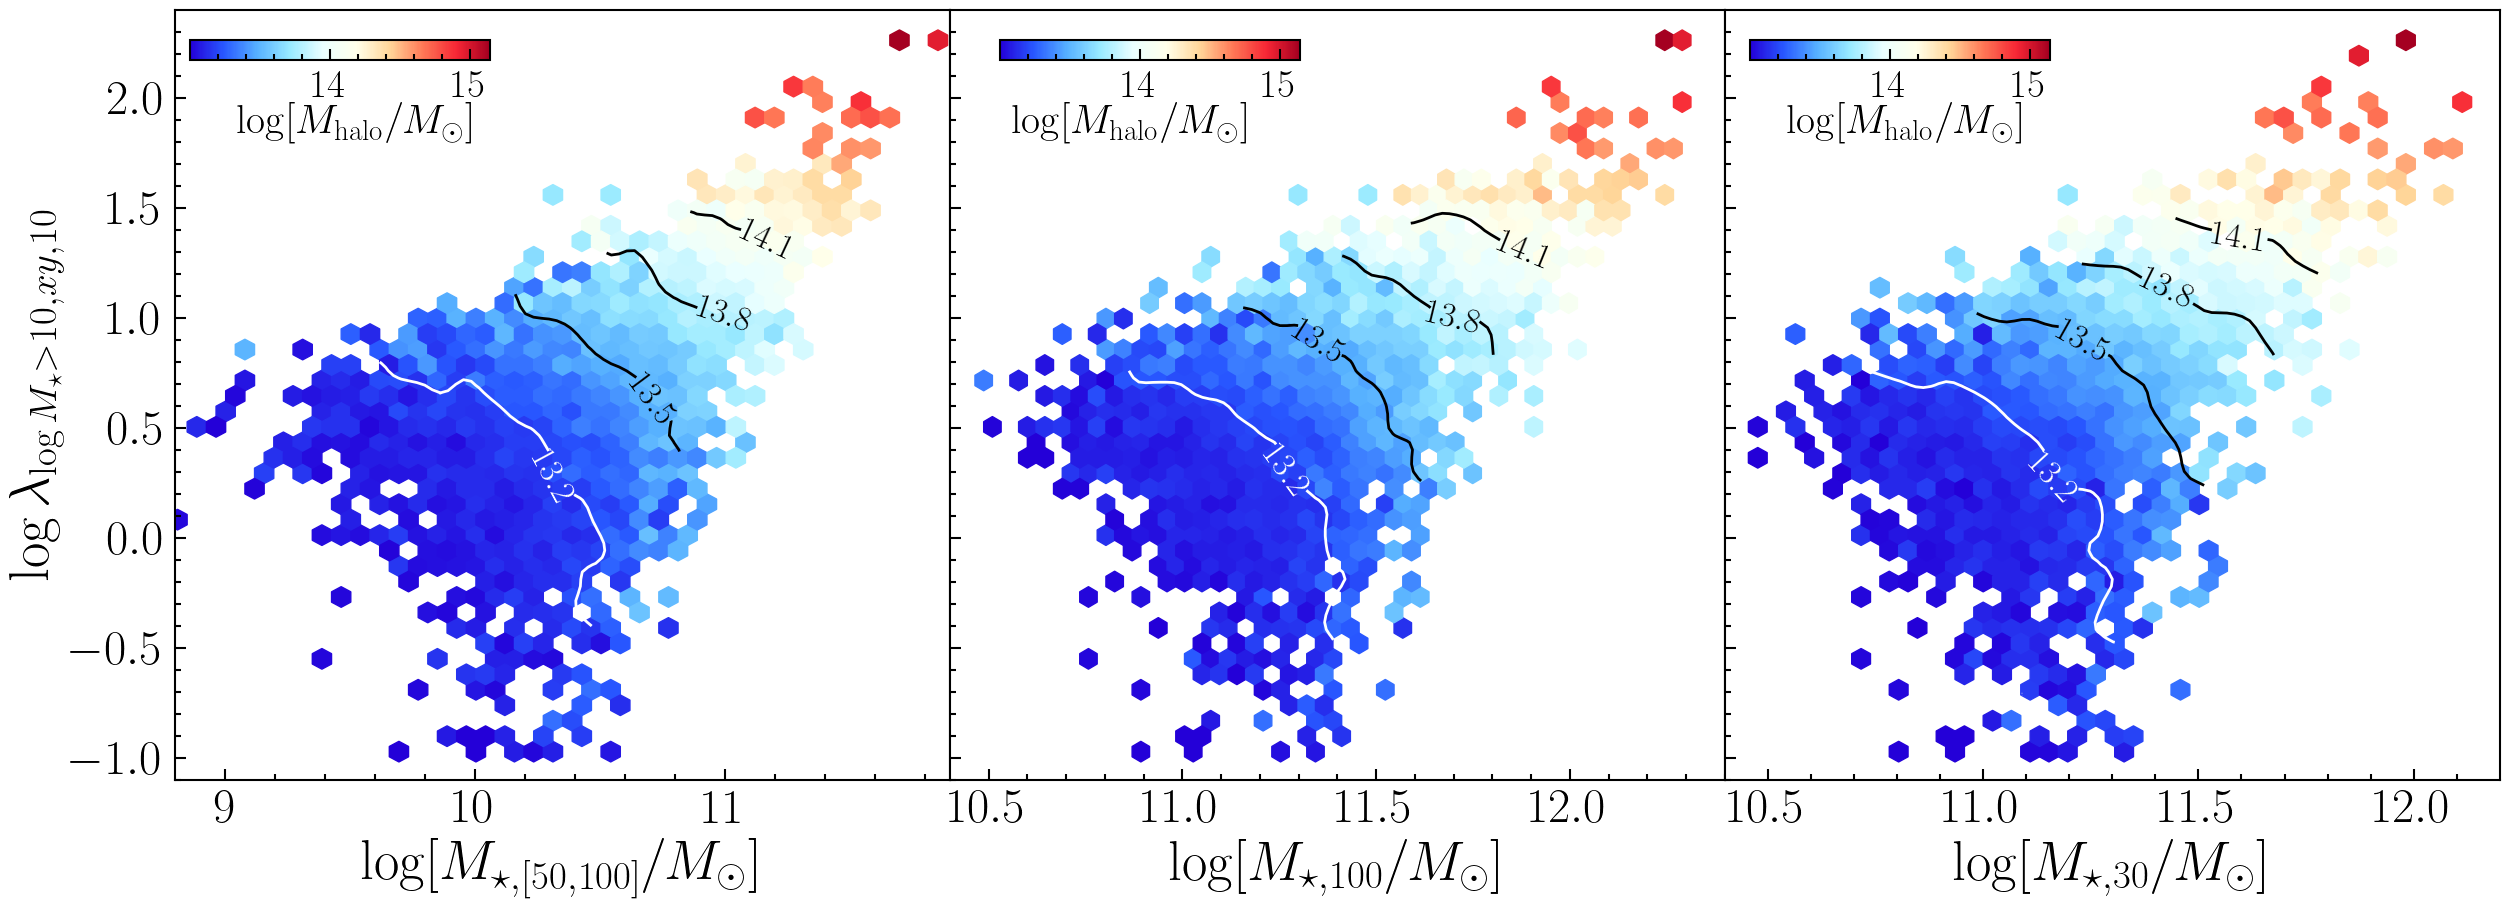

In [15]:
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
axlist=gs.subplots(sharey='row')
top_numb=600
sigma0=1.7

ax3=axlist[0]

name='richness_cut_r200_10_xy_10'
label=r'$\log\lambda_{\log M_\star>10,xy,10}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(10,0.2),(10.6,0.5),(11,1),(11.2,1.4)],fontsize=25)

ax3.set_ylabel(label,fontsize=40)
ax3.set_xlabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(8.8,11.9)
ax3=axlist[1]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.4, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11.0,0),(11.3,0.8),(11.7,1),(11.9,1.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,100}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(10.4,12.4)
ax3=axlist[2]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_30_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11.0,0),(11.2,0.8),(11.4,1),(11.6,1.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)

ax3.set_ylim(-1.1,2.4)
ax3.set_xlim(10.4,12.2)

(10.4, 12.2)

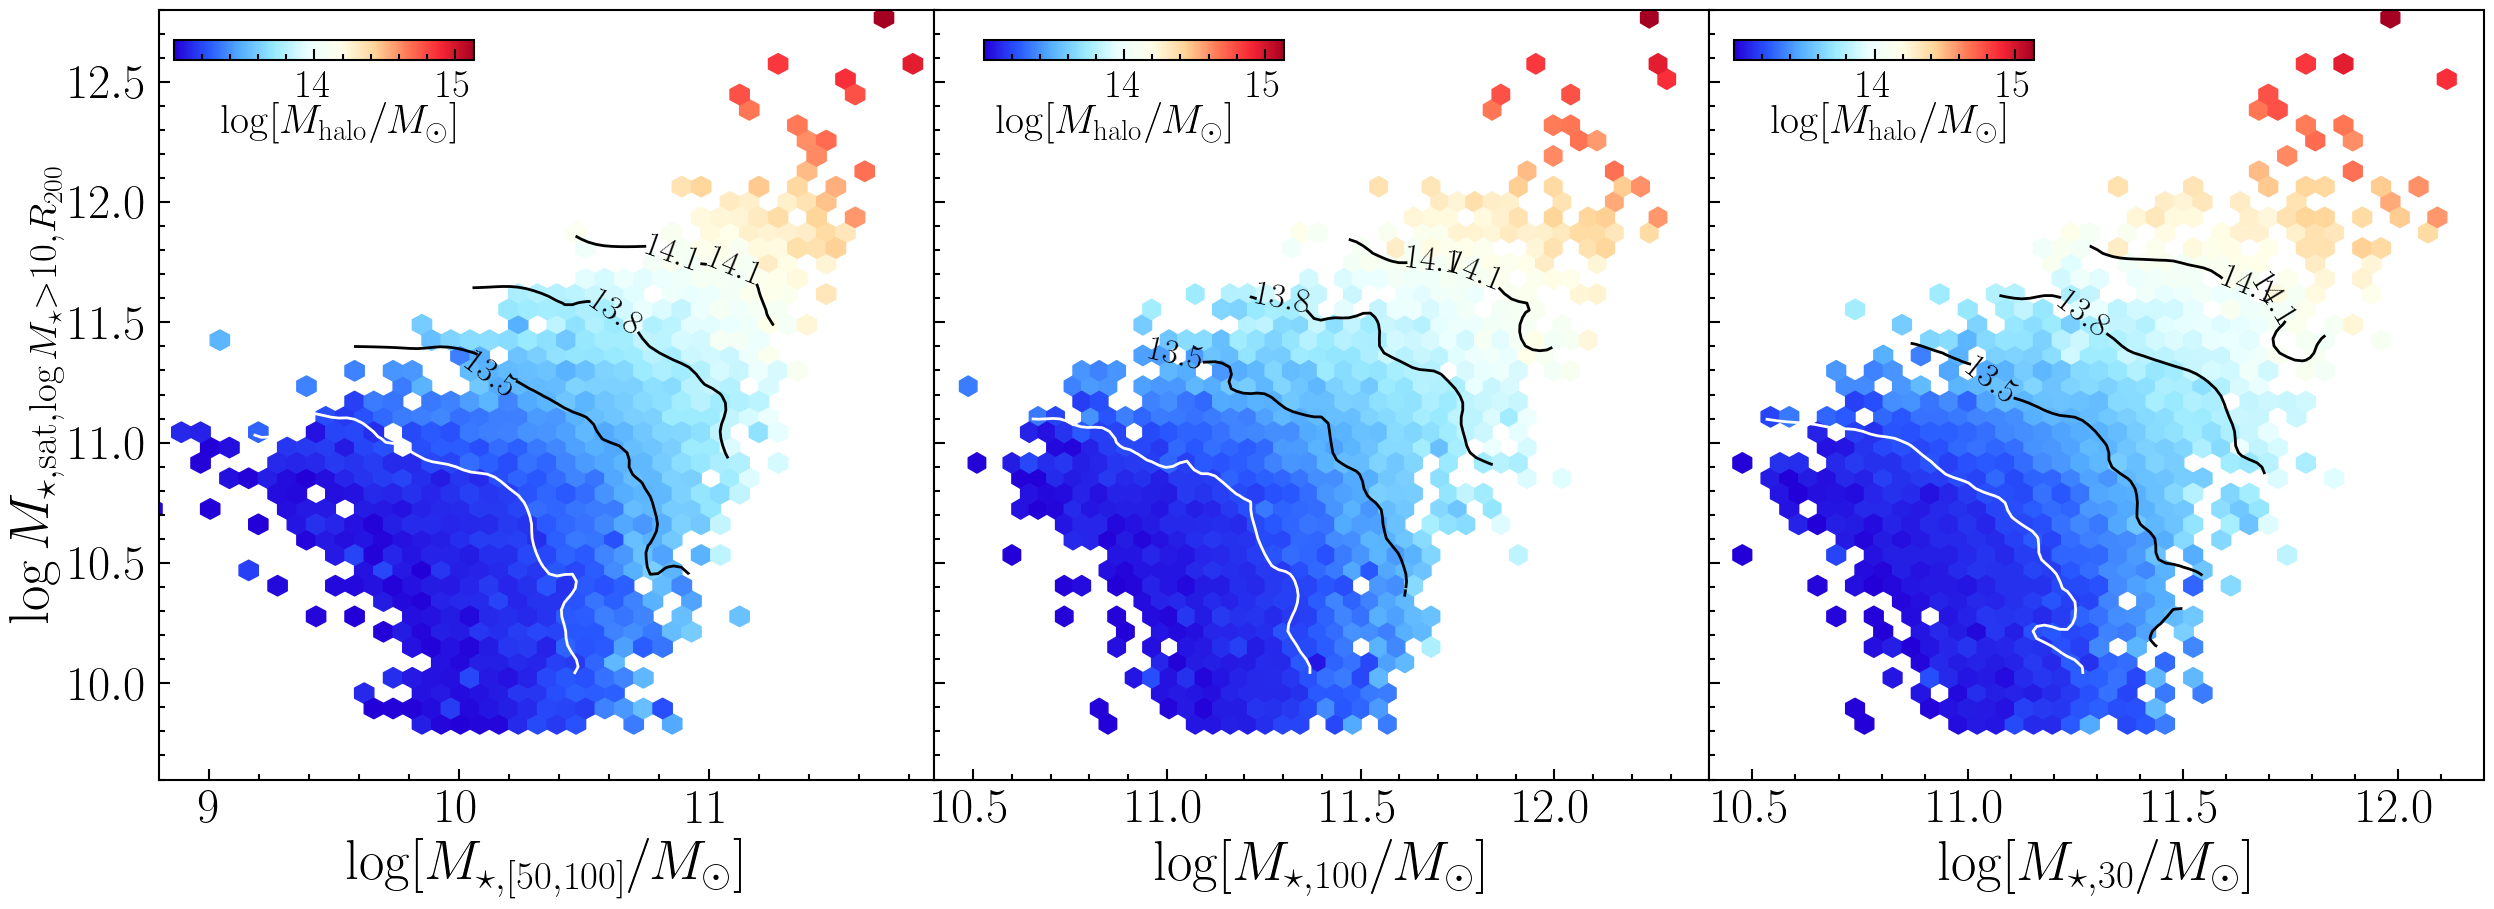

In [22]:
fig=plt.figure(figsize=(30,10))
gs = fig.add_gridspec(1,3, hspace=0, wspace=0)
axlist=gs.subplots(sharey='row')
top_numb=600
sigma0=1.5

ax3=axlist[0]

name='satellite_mass_cut_r200_10'
label=r'$\log M_{\star,{\rm sat},\log M_\star>10,R_{200}}$'
tab_x=tab2[name]
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.13, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(10,11.2),(10.6,11.5),(11,12),(11.2,12.4)],fontsize=25)

ax3.set_ylabel(label,fontsize=40)
ax3.set_xlabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax3.set_ylim(9.6,12.8)
ax3.set_xlim(8.8,11.9)
ax3=axlist[1]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.4, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11,11.2),(11.3,11.6),(11.7,12),(11.9,12.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,100}/M_\odot]$',fontsize=40)

ax3.set_ylim(9.6,12.8)
ax3.set_xlim(10.4,12.4)
ax3=axlist[2]


mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_30_gal'])


zdata=np.log10(tab2[mask10]['mass_halo'])
SC=ax3.hexbin(ydata,xdata,C=zdata,cmap=cmap1,gridsize=40)
ax3.text(0.08,0.84,r'$\log[M_{\rm halo}/M_\odot]$',transform=ax3.transAxes,size=30)
cax = fig.add_axes([0.65, 0.83, 0.1, 0.02])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


x=ydata
y=xdata
values = np.vstack([x, y])
kernel = gaussian_kde(values)

grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),  # More grid points for smoothness
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the z-values (third property) onto the grid
grid_z = griddata((x, y), zdata, (grid_x, grid_y), method='linear')  # Use cubic interpolation

# Smooth the interpolated grid using a Gaussian filter
grid_z_s = gaussian_filter(grid_z, sigma=sigma0)

CS0=ax3.contour(grid_x, grid_y, grid_z_s, levels=[13.2,13.5,13.8,14.1],
            colors=['white','black','black','black'],linewidths=2)

fmt={}
str0=[r'$13.2$',r'$13.5$',r'$13.8$',r'$14.1$']
for l, s in zip(CS0.levels, str0):
    fmt[l] = s
ax3.clabel(CS0,inline=True,fmt=fmt,inline_spacing=1,manual=[(11,11.2),(11.3,11.6),(11.7,12),(11.9,12.4)],fontsize=25)

ax3.set_xlabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)

ax3.set_ylim(9.6,12.8)
ax3.set_xlim(10.4,12.2)